# **Cost Benefit Analysis**
---
This is where we'll turn our model's predictions from "the model has 83% recall" into a business case with real dollar figures with results like "targeting these specific customers saves the business $X net of retention costs." 

In this notebook, I will:
1. load predictions and set business assumptions
2. segment the flagged customers
3. calculate ROI per tier
4. then export the retention recommendations

### **Imports and loading data**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/xgb_predictions.csv')
print(df.shape)
df.head()

(1409, 33)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,MultipleLines_No phone service,...,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Actual_Churn,Churn_Probability,Predicted_Churn
0,1,0,1,1,72,1,1,114.05,8468.20,False,...,False,True,False,True,True,False,False,0,0.007723,0
1,0,1,0,0,8,1,1,100.15,908.55,False,...,False,True,False,False,True,False,False,0,0.799349,1
2,0,0,1,1,41,1,1,78.35,3211.20,False,...,False,False,True,False,True,False,False,0,0.067187,0
3,1,0,1,0,18,1,0,78.20,1468.75,False,...,False,False,False,False,False,True,False,0,0.280737,1
4,0,0,1,0,72,1,1,82.65,5919.35,False,...,False,True,False,True,True,False,False,0,0.005695,0


### **Business Assumptions**

These are what will basically control the analysis based on the dataset averages and standard retention campaign costs

In [2]:
MONTHLY_REVENUE = 64.76  # average MonthlyCharges from the dataset
RETENTION_OFFER_COST = 15.00  # cost of one retention offer (discount/incentive)
RETENTION_SUCCESS_RATE = 0.30  # industry standard benchmark: 30% of at-risk customers accept and stay
CUSTOMER_LIFETIME = 12   # months estimmate of retained value

print(f"Average monthly revenue per customer: ${MONTHLY_REVENUE}")
print(f"Retention offer cost: ${RETENTION_OFFER_COST}")
print(f"Assumed retention success rate: {RETENTION_SUCCESS_RATE*100}%")
print(f"Customer lifetime assumption: {CUSTOMER_LIFETIME} months")

# note that these can be challenged and adjusted by the customer but it's important to be clear about them from the start with proper justifications.

Average monthly revenue per customer: $64.76
Retention offer cost: $15.0
Assumed retention success rate: 30.0%
Customer lifetime assumption: 12 months


### **Isolating flagged customers and ranking by risk**
---
Of the 601 customers that were flagged (check modelling.ipynb), who are the highest priority?

What we'll do is to rank them by **churn probability score** and **create tiers** say top 100, top 200, top 300, so that a *business can decide how much retention budget to deploy.*

In [3]:
# looking at only customers the model flagged as churn risk
flagged = df[df['Predicted_Churn'] == 1].copy()
flagged = flagged.sort_values('Churn_Probability', ascending=False).reset_index(drop=True)

print(f"Total flagged: {len(flagged)}")
print(f"Of which are real churners: {flagged['Actual_Churn'].sum()}")
print(f"\nProbability score distribution:")
print(flagged['Churn_Probability'].describe().round(3))

Total flagged: 601
Of which are real churners: 309

Probability score distribution:
count    601.000
mean       0.523
std        0.176
min        0.251
25%        0.378
50%        0.499
75%        0.653
max        0.930
Name: Churn_Probability, dtype: float64


### **Assigning risk tiers**
---
Here is where we do the actual segmentation of the 601 flagged customers into **three buckets by confidence level.** 

High risk customers should be contacted first as they're the most likely to leave and the most urgent to act on.

In [4]:
def assign_tier(prob):
    if prob >= 0.70:
        return 'High risk'
    elif prob >= 0.50:
        return 'Medium risk'
    else:
        return 'Low risk'

flagged['Risk_Tier'] = flagged['Churn_Probability'].apply(assign_tier)

print(flagged['Risk_Tier'].value_counts())

Risk_Tier
Low risk       302
Medium risk    182
High risk      117
Name: count, dtype: int64


### **Calculating the Return on Investment (ROI) per risk tier**
---
*why?*
Because for each tier calculated, we need to know:
- what does it cost to run the campaign?
- how many customers will we actually retain (flagged × real churners × 30% success rate)?
- and what's the net dollar value after subtracting offer costs?

So the **ROI tells us which tier gives the best return per dollar spent.**

In [5]:
tier_results = []

for tier in ['High risk', 'Medium risk', 'Low risk']:
    group = flagged[flagged['Risk_Tier'] == tier]
    n_customers = len(group)
    n_real_churners = group['Actual_Churn'].sum()
    
    campaign_cost = n_customers * RETENTION_OFFER_COST
    customers_saved = n_real_churners * RETENTION_SUCCESS_RATE
    revenue_saved = customers_saved * MONTHLY_REVENUE * CUSTOMER_LIFETIME
    net_value = revenue_saved - campaign_cost
    roi = (net_value / campaign_cost * 100) if campaign_cost > 0 else 0
    
    tier_results.append({
        'Risk Tier': tier,
        'Customers Flagged': n_customers,
        'Actual Churners': int(n_real_churners),
        'Campaign Cost ($)': round(campaign_cost, 2),
        'Est. Revenue Saved ($)': round(revenue_saved, 2),
        'Net Value ($)': round(net_value, 2),
        'ROI (%)': round(roi, 1)
    })

roi_df = pd.DataFrame(tier_results)
print(roi_df.to_string(index=False))

  Risk Tier  Customers Flagged  Actual Churners  Campaign Cost ($)  Est. Revenue Saved ($)  Net Value ($)  ROI (%)
  High risk                117               90             1755.0                20982.24       19227.24   1095.6
Medium risk                182              106             2730.0                24712.42       21982.42    805.2
   Low risk                302              113             4530.0                26344.37       21814.37    481.6


### **Putting all the results together so far:**

In [23]:
total_cost = roi_df['Campaign Cost ($)'].sum()
total_saved = roi_df['Est. Revenue Saved ($)'].sum()
total_net = roi_df['Net Value ($)'].sum()
total_roi = (total_net / total_cost * 100)

print("-" * 50)
print("Full Campaign Summary")
print("-" * 50)
print(f"Total customers targeted:                           {len(flagged)}")
print(f"Total campaign cost:                            ${total_cost:,.2f}")
print(f"Total estimated revenue saved:            ${total_saved:,.2f}")
print(f"Total net value:                                    ${total_net:,.2f}")
print(f"Overall ROI:                                          {total_roi:.1f}%")

--------------------------------------------------
Full Campaign Summary
--------------------------------------------------
Total customers targeted:                           601
Total campaign cost:                            $9,015.00
Total estimated revenue saved:            $72,039.03
Total net value:                                    $63,024.03
Overall ROI:                                          699.1%


#### *Observation and Insights:*
---
A **~$63,024 net value** at **699% ROI** is a strong result. This means that **for every $1 spent on retention offers, the business gets back $7.**

### **Visualising the ROI by the risk tiers**

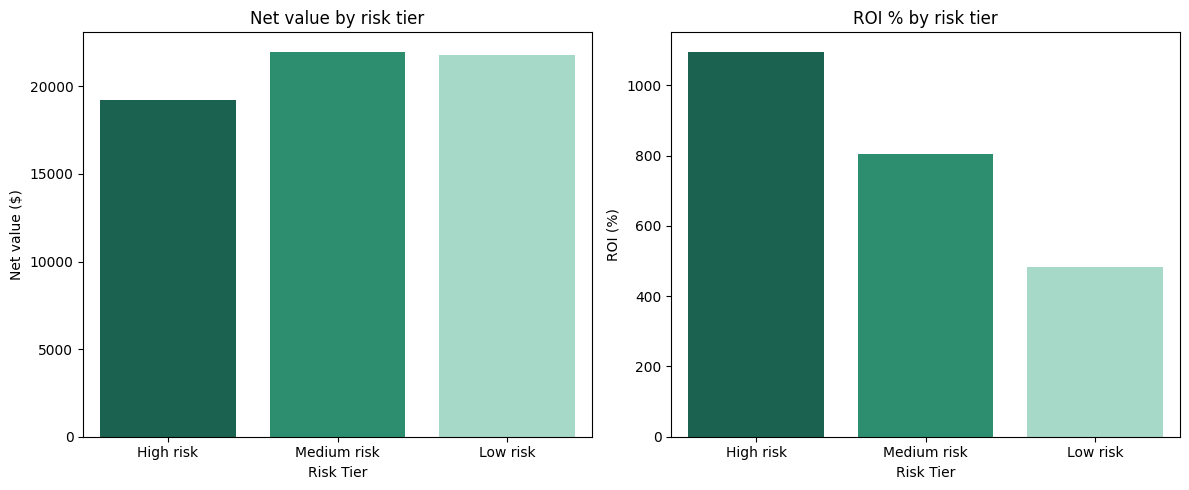

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# net value by tier
sns.barplot(data=roi_df, x='Risk Tier', y='Net Value ($)', hue='Risk Tier',
            palette=['#0F6E56', '#1D9E75', '#9FE1CB'], legend=False, ax=axes[0])
axes[0].set_title('Net value by risk tier')
axes[0].set_ylabel('Net value ($)')

# seeing the ROI percentage % by risk tier  
sns.barplot(data=roi_df, x='Risk Tier', y='ROI (%)', hue='Risk Tier',
            palette=['#0F6E56', '#1D9E75', '#9FE1CB'], legend=False, ax=axes[1])
axes[1].set_title('ROI % by risk tier')
axes[1].set_ylabel('ROI (%)')

plt.tight_layout()
plt.savefig('../outputs/roi_by_tier.png', bbox_inches='tight')
plt.show()

#### *Observation and Insights:*
---
- High risk has the highest ROI (1,060%) but not the highest net value.
- Medium risk has the highest net value ($22,000) despite lower ROI. This is because there are more medium risk customers as *more volume means more total revenue saved* even though each dollar works slightly harder in the high risk tier.
---
For the business, this would mean that **if their budget is limited**, they should **start with high risk customers first as it has the best return per dollar spent.**
And if budget allows, expanding to medium risk adds the most absolute revenue.
Low risk customers remain ROI-positive but should only be targeted if retention budget allows after high and medium tiers are covered.

### **Visualizing the Churn Probability Distribution of Flagged Customers**

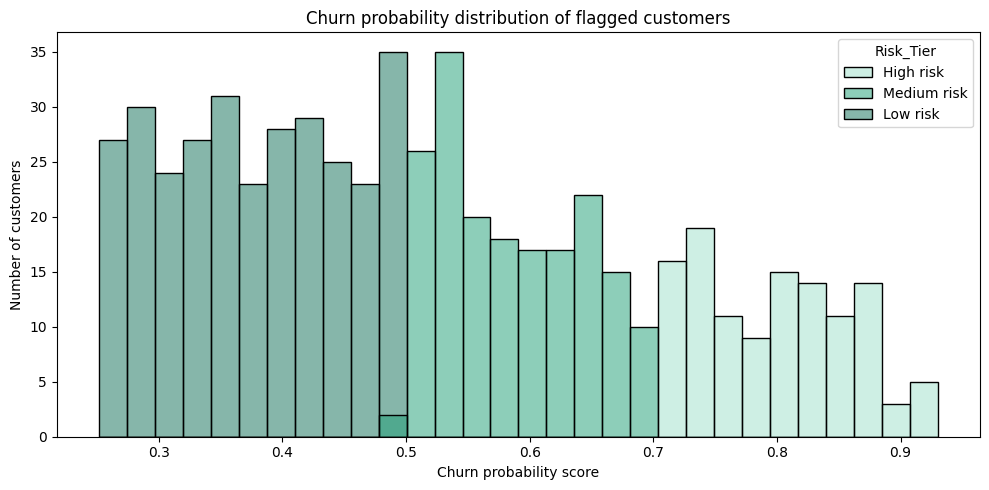

In [26]:
plt.figure(figsize=(10, 5))
sns.histplot(data=flagged, x='Churn_Probability', hue='Risk_Tier',
             bins=30, palette=['#9FE1CB', '#1D9E75', '#0F6E56'])

plt.title('Churn probability distribution of flagged customers')
plt.xlabel('Churn probability score')
plt.ylabel('Number of customers')
plt.tight_layout()

plt.savefig('../outputs/churn_probability_distribution.png', bbox_inches='tight')
plt.show()

#### *Observation and Insights:*
---
- The majority of flagged customers cluster between probability scores of 0.25 and 0.55, reflecting the wide net cast by the 0.25 threshold. 
- A smaller but high-confidence group sits above 0.70. 
    - These are the customers the model is most certain about. 
    - Inspection of the top-ranked customers confirms the model's accuracy: the 10 highest-probability customers are all genuine churners, mostly new customers (tenure 1–7 months) on high monthly charges between $70–$106.
- **New, high-paying customers on short-tenure contracts represent the most urgent retention priority.**

### **Exporting Retention Recommendations**
---
*Our actual deliverable!*: **a ranked list of at-risk customers with a recommended action per tier and estimated revenue at stake per customer.**

This is what a marketing or customer success team would open on Monday morning haha.

In [27]:
recommendations = flagged[['Churn_Probability', 'Risk_Tier', 
                             'Actual_Churn', 'MonthlyCharges', 
                             'tenure']].copy()

recommendations['Recommended_Action'] = recommendations['Risk_Tier'].map({
    'High risk': 'Priority outreach: offer loyalty discount immediately',
    'Medium risk': 'Schedule retention call within 2 weeks',
    'Low risk': 'Monitor and include in next email campaign'
})

recommendations['Est_Revenue_At_Risk'] = (
    recommendations['MonthlyCharges'] * CUSTOMER_LIFETIME
).round(2)

recommendations = recommendations.sort_values('Churn_Probability', ascending=False)
recommendations.to_csv('../outputs/retention_recommendations.csv', index=False)

print(f"Exported {len(recommendations)} recommendations")
print(recommendations.head(10))

Exported 601 recommendations
   Churn_Probability  Risk_Tier  Actual_Churn  MonthlyCharges  tenure  \
0           0.930366  High risk             1           95.10       1   
1           0.928253  High risk             1           85.05       1   
2           0.920048  High risk             1           76.45       1   
3           0.914853  High risk             1           95.45       1   
4           0.908154  High risk             1           77.15       1   
5           0.901916  High risk             1          105.90       3   
6           0.894542  High risk             1           85.00       1   
7           0.894137  High risk             1           90.85       1   
8           0.884329  High risk             1           69.60       1   
9           0.884108  High risk             1           99.25       7   

                                  Recommended_Action  Est_Revenue_At_Risk  
0  Priority outreach: offer loyalty discount imme...               1141.2  
1  Priority out

#### *Observation and Insights:*
---
601 customers flagged and ranked by churn probability, with recommended actions assigned per tier:
- High risk (≥ 0.70): priority outreach, **immediate loyalty discount**
- Medium risk (0.50–0.70): **retention call within 2 weeks** 
- Low risk (0.25–0.50): **monitor, include in next email campaign**

---
Estimated revenue at risk per customer ranges from **$835 to $1,271 over a 12-month horizon, based on individual monthly charges.** 
*The top 10 highest-risk customers alone represent over $10,500 in revenue at risk.*

## **Cost-Benefit Summary**
---
Using XGBoost at threshold 0.25, the model flagged 601 customers as churn risks across three tiers. Applying a ***30% industry-standard retention success rate*** and a ***12-month customer lifetime value assumption***, the **full retention campaign generates positive ROI across all tiers.**

*Our key assumptions:*
- Average monthly revenue per customer: $64.76
- Retention offer cost: $15 per customer
- Retention success rate: 30%
- Customer lifetime: 12 months

**Outputs and Interpretation:**
| Metric | Value |
|---|---|
| Customers targeted | 601 |
| Total campaign cost | $9,015 |
| Estimated revenue saved | $72,039 |
| Net value | $63,024 |
| Overall ROI | 699% |

- High risk customers deliver the strongest ROI (1,060%) and should be prioritised for immediate outreach. 
- Medium risk customers contribute the highest absolute net value and should be included in all campaigns.

**DISCLAIMER**

---
*These figures are estimates based on dataset averages and assumed retention rates.* 
Actual results would vary based on real offer costs, customer lifetime data, and measured retention conversion rates. 
The model provides a prioritised, actionable list for the business so they can determine the final offer strategy and budget allocation.


Finally, the full recommendations are exported to `outputs/retention_recommendations.csv`.